In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
#Defining parameters

N = 100
t = 1.0
Delta0  = 1.0
mu0=4.0



In [19]:
#Site dependent chemical potentials

mu = np.zeros(N)

#Site dependent pairing

Delta = np.zeros(N)

In [20]:
#Building interface

for i in range(N):
    #Superconducting region
    if i <N//2:
        mu[i] = 0
        Delta[i] = Delta0
    else:
        #Backscattering region
        mu[i] = mu0
        Delta[i]= 0

In [21]:
#Hamiltonian

h = np.zeros((N,N))

for i in range(N):
    h[i,i] = -mu[i]

for i in range(N-1):
    h[i,i+1] = -t
    h[i+1,i] = -t

#Pairing matrix

pair = np.zeros((N,N))

for i in range(N-1):
    pair[i,i+1] = Delta[i]
    pair[i+1,i] = -Delta[i]

#BdG Hamiltonian

top = np.hstack((h,pair))
bottom = np.hstack((-pair.T,-h.T))

Hbdg = np.vstack((top,bottom))
    

In [22]:
#Diagonalization

E, V = np.linalg.eigh(Hbdg)

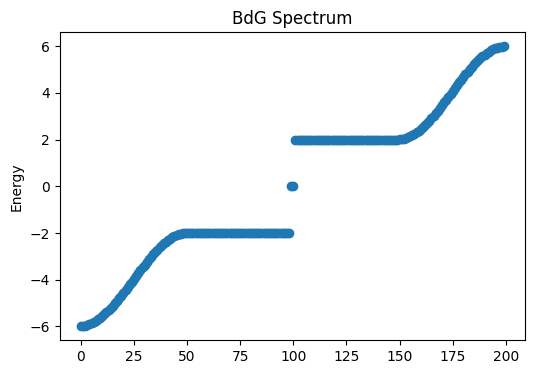

In [23]:
#Plot Spectrum

plt.figure(figsize = (6,4))
plt.plot(E,'o')
plt.ylabel("Energy")
plt.title("BdG Spectrum")
plt.show()

In [24]:
#Find lowest energy state

idx = np.argmin(np.abs(E))

u = V[:N,idx]
v = V[N:,idx]

density = np.abs(u)**2 + np.abs(v)**2

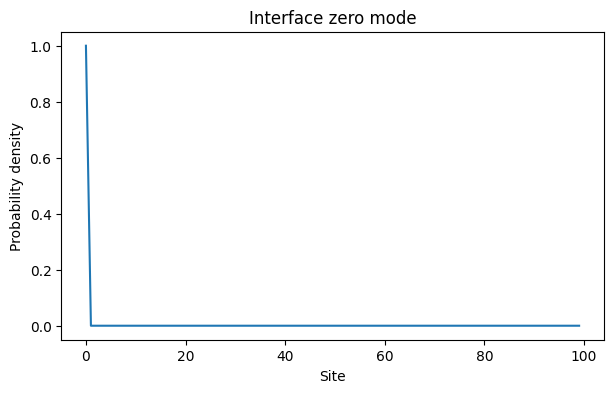

Lowest energy = 3.11305607072287e-16


In [25]:
#plot of wavefunction

plt.figure(figsize = (7,4))
plt.plot(density)
plt.xlabel("Site")
plt.ylabel("Probability density")
plt.title("Interface zero mode")
plt.show()

print("Lowest energy =", E[idx])

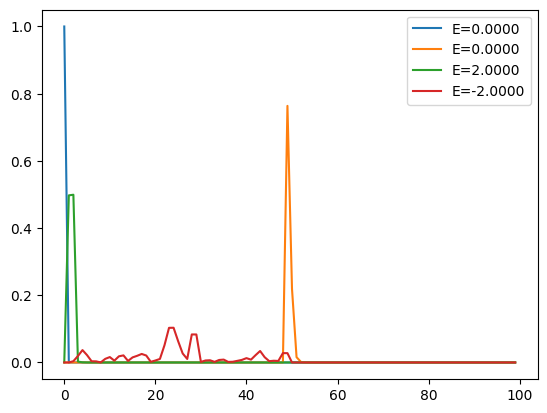

In [26]:
#Excited states

for n in range(4):

    idx = np.argsort(np.abs(E))[n]

    u = V[:N, idx]
    v = V[N:, idx]

    density = np.abs(u)**2 + np.abs(v)**2

    plt.plot(density, label=f"E={E[idx]:.4f}")

plt.legend()
plt.show()

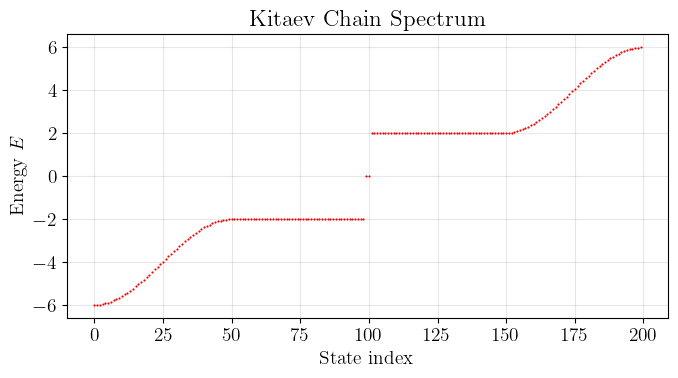

In [28]:
# Gráfico mais bonito
plt.rcParams.update({
    "text.usetex": True,      # usa LaTeX
    "font.family": "serif",
    "font.size": 14,
})

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(
    E,
    'o',
    color='red',
    markersize=1,     # pontos menores
    markeredgewidth=0.5
)

ax.set_xlabel(r"State index")
ax.set_ylabel(r"Energy $E$")
ax.set_title(r"Kitaev Chain Spectrum")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()